# **A Simple PINN**

## 1. Theory

Compared with typical feed-forward neural networks, Physics-Informed Neural Networks (PINNs) incorporate an additional physics-informed loss term derived from the governing equations. The primary architectural difference is not necessarily the number of layers or neurons, but rather the inclusion of physics loss terms during optimisation. Given our toy problem, that of a cooling object governed by a single differential equation (Newton’s law of cooling), we only have a single PDE residual. Given the simplicity of our problem, a PINN can learn without adding any terms to enforce the initial condition $T(t=0)=T_0$ within the loss function $\mathcal{L}$,

$$
\mathcal{L} = \mathcal{L}_{\text{data}} + \lambda_{\text{PDE}} \mathcal{L}_{\text{PDE}} + \cancel{\lambda_{\text{con}} \mathcal{L}_{\text{con}}}
$$

Since we only have a single governing equation for the physical process, there is only a single PDE (now ODE) residual $\delta_T$ used in our physics-informed loss term $\mathcal{L}_{{PDE}}$. Its form is,

$$
\delta_T = \frac{dT}{dt} + \alpha (T - T_s)
$$

$T$ is the temperature of the object and is a function of time, while $T_s$ is the temperature of the surroundings. In some PINNs, the physics-informed loss is calculated using only collocation points. This is the case in our example. To be explicit, collocation points are points which are sampled across the entire domain but lack a corresponding label. Collocation points are unsupervised and used to enforce the PDE (ODE in our example) dynamics over the entire domain. It should be noted that in our case, we make a distinction between collocation and data points because the labelled data has been sampled from a restricted domain. This was done to showcase that PINNs can generalise to unseen data by encoding physics through unsupervised learning. The physics-informed loss is constructed from the squared residual averaged over all randomly drawn collocation points during each batch iteration. Our ODE loss term is written as,

$$
\mathcal{L}{\text{PDE}} = \frac{1}{N_c} \sum^{N_c}{c=1} \left( \frac{d\hat{T}}{dt_c} + \alpha [\hat{T}(t_c) - T_s] \right)^2
$$

where $N_c$ is the number of collocation points per batch and $\hat{T}(t_c)$ is the model’s temperature predicion at the collocation point $t_c$. $N_c$ is kept fixed across all batch iterations of the optimisation process and is an additional hyperparameter that must be tuned accordingly. Note that during each batch, the collocation points are randomly drawn from the entire temporal domain. With this in mind, the full physics-informed loss function $\mathcal{L}$ can be written as,

$$
\mathcal{L} = \frac{1}{N} \sum^{N}{i=1} [T(t_i) - \hat{T}(t_i)]^2 + \frac{\lambda}{N_c} \sum^{N_c}{c=1} \left( \frac{d\hat{T}}{dt_c} + \alpha [\hat{T}(t_c) - T_s] \right)^2
$$

where $\lambda$ is a hyperparameter that controls how strongly the network considers the ODE residual. It is important to distinguish the difference between $T(t_i)$, which is the model prediction on a supervised data point $t_i$ that has the associated label $T(t_i)$, versus the model prediction $\hat{T}(t_c)$ on the collocation point $t_c$.

### 2. Loading Data 

Let us first import the required modules,

In [1]:
# PyTorch imports,
import torch # <-- PyTorch
from torch.nn import Linear
from torch.utils.data import Dataset, DataLoader # <-- Wrappers for the data.
from torch.optim import Adam
import torch.nn.functional as F
from torchinfo import summary

# Importing,
import numpy as np
import matplotlib.pyplot as plt
import sys

# Printing versions,
print("System Version:", sys.version)
print("PyTorch version", torch.__version__)
print("Numpy version", np.__version__)

System Version: 3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 13:17:27) [MSC v.1929 64 bit (AMD64)]
PyTorch version 2.6.0+cpu
Numpy version 1.26.4


Now we must create the a `Dataset` class for our data,

In [2]:
class MyDataset(Dataset):
    """Loads the data for the model."""

    def __init__(self, train=True):

        # Boolean logic for dataset,
        if train:
            Xy = np.load("train.npy")
        else:
            Xy = np.load("test.npy")

        # Extracting input and target,
        self.X, self.y = Xy[0], Xy[1]
        self.n_samples = Xy.shape[1]

        # Converting to Tensors (float32 type),
        self.X = torch.from_numpy(self.X.astype(np.float32)).unsqueeze(1)
        self.y = torch.from_numpy(self.y.astype(np.float32)).unsqueeze(1)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]
    
    def __len__(self):
        return self.n_samples

Creating the dataloader for the training data,

In [3]:
# Loading data,
train_data = MyDataset(train=True)
test_data = MyDataset(train=False)

# Creating dataloaders,
BATCH_SIZE = 16
train_loader = DataLoader(dataset=train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(dataset=test_data, batch_size=BATCH_SIZE, shuffle=True)

We inspect the data quickly,

In [4]:
for (X, y) in train_loader:
    print(f"X: {X.shape}, y: {y.shape}")
    break

X: torch.Size([16, 1]), y: torch.Size([16, 1])


For this toy example, we do not bother scaling the data. However, for more complicated physical systems, scaling is required to improve stability and also increase convergence speed.

### 3. Model Creation

The PINN architecture consists of a fully connected feed-forward neural network with four hidden layers containing 32 neurons each. Moreover, the network uses the hyperbolic tangent $\text{tanh}(x)$ activation function in each hidden layer. This choice of activation function is important because PINNs require derivatives of the network output with respect to the input variables in order to evaluate the physics-informed loss. Since $\text{tanh}(x)$ is smooth and infinitely differentiable, it allows automatic differentiation to compute stable and continuous derivatives required for the ODE residual. In contrast, non-smooth activations such as ReLU can introduce difficulties because their derivatives are discontinuous, making them less suitable for physics-based constraints. Specifically for ReLU, its derivative is discontinuous at zero and its second derivative is zero almost everywhere. This poses a big issue when the PDE residuals involve the computation of higher order derivatives. 

In [6]:
class Model(torch.nn.Module):
    """The neural network architecture."""

    def __init__(self):
        """Constuctor method. Builds the neural network."""
        super(Model, self).__init__()

        # Creating model layers,
        self.fc1 = Linear(in_features=1, out_features=16)
        self.fc2 = Linear(in_features=16, out_features=16)
        self.fc3 = Linear(in_features=16, out_features=16)
        self.fc4 = Linear(in_features=16, out_features=16)
        self.fc5 = Linear(in_features=16, out_features=1)

    def forward(self, x):
        """Defines the forward propagation of the neural network."""

        x = F.tanh(self.fc1(x))
        x = F.tanh(self.fc2(x))
        x = F.tanh(self.fc3(x))
        x = F.tanh(self.fc4(x))
        x = self.fc5(x)

        return x

Testing the forward propagation using `torchinfo`,

In [7]:
# Creating the neural network,
model = Model()
summary(model, input_size=(BATCH_SIZE, 1))

Layer (type:depth-idx)                   Output Shape              Param #
Model                                    [16, 1]                   --
├─Linear: 1-1                            [16, 16]                  32
├─Linear: 1-2                            [16, 16]                  272
├─Linear: 1-3                            [16, 16]                  272
├─Linear: 1-4                            [16, 16]                  272
├─Linear: 1-5                            [16, 1]                   17
Total params: 865
Trainable params: 865
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.01
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.00
Estimated Total Size (MB): 0.01

### 4. Loss Function

Now we create the physics informed loss function that encodes the physical laws via an ODE residual,

In [8]:
def grad(outputs, inputs):
    """Computes the partial derivative of an output with respect to an input. Returns the gradient directly."""
    return torch.autograd.grad(
        outputs, 
        inputs, 
        grad_outputs=torch.ones_like(outputs), 
        create_graph=True
    )[0]

class CustomLoss(torch.nn.Module):
    """Implements the entire physics informed loss function."""
    def __init__(self, lambda_const, alpha=2.5, T_s=1):
        super(CustomLoss, self).__init__()
        self.lambda_const = lambda_const
        self.alpha = alpha
        self.T_s = T_s

    def forward(self, X_coll, y, y_pred, y_coll):
        """Forward propagation of the loss function."""

        # Data-driven loss,
        mse_loss = torch.mean((y_pred - y) ** 2)

        # Computing physics loss,
        dTdt = grad(y_coll, X_coll)
        residual = dTdt + self.alpha*(y_coll - self.T_s)
        physics_loss = torch.mean(residual**2)
        return mse_loss + self.lambda_const*physics_loss

### 5. Model Training

In [9]:
# Hyperparameters,
n_coll = 4
max_epochs = 250
lr = 1e-3
lambda_param = 1e-2

# Enabling CUDA (if possible),
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model.to(device)
print(f"Training on: {device}")

# Creating the optimiser,
optimiser = Adam(model.parameters(), lr=lr)

# Specifying the loss function,
loss_fn = CustomLoss(lambda_const=lambda_param)

"""TRAINING LOOP"""
train_losses = []
val_losses = []
for epoch in range(1, max_epochs+1):

    """================= TRAIN ================="""
    model.train() # <-- Training mode.
    train_running_loss = 0.0

    # Batch loop,
    for (X, y) in train_loader:
        optimiser.zero_grad() # Clear gradients,
        X, y = X.to(device), y.to(device) # Moving tensors to training device.
        y_pred = model(X) # Forward pass (data points).

        """================= COLOCATION POINTS ================="""
        X_coll = 5*torch.rand(n_coll, 1).to(device)
        X_coll = X_coll.unsqueeze(1).to(device).requires_grad_(True)
        y_coll = model(X_coll)

        loss = loss_fn(X_coll, y, y_pred, y_coll) # Computing loss.
        loss.backward() # Backward pass.
        optimiser.step() # Parameter update.

        # Tracking loss,
        train_running_loss += loss.item()

    train_loss = train_running_loss/len(train_loader)
    train_losses.append(train_loss)

    # Printing,
    print(f"Epoch {epoch} | training_loss: {train_loss:.6f}")

Training on: cpu
Epoch 1 | training_loss: 8.089965
Epoch 2 | training_loss: 6.932562
Epoch 3 | training_loss: 5.479438
Epoch 4 | training_loss: 3.781614
Epoch 5 | training_loss: 2.423351
Epoch 6 | training_loss: 1.609492
Epoch 7 | training_loss: 1.190740
Epoch 8 | training_loss: 1.060727
Epoch 9 | training_loss: 0.990071
Epoch 10 | training_loss: 0.990501
Epoch 11 | training_loss: 0.959655
Epoch 12 | training_loss: 0.959830
Epoch 13 | training_loss: 0.958449
Epoch 14 | training_loss: 0.960937
Epoch 15 | training_loss: 0.953401
Epoch 16 | training_loss: 0.926012
Epoch 17 | training_loss: 0.905562
Epoch 18 | training_loss: 0.879740
Epoch 19 | training_loss: 0.861691
Epoch 20 | training_loss: 0.827594
Epoch 21 | training_loss: 0.760218
Epoch 22 | training_loss: 0.661843
Epoch 23 | training_loss: 0.590670
Epoch 24 | training_loss: 0.486462
Epoch 25 | training_loss: 0.385403
Epoch 26 | training_loss: 0.304805
Epoch 27 | training_loss: 0.240266
Epoch 28 | training_loss: 0.213919
Epoch 29 | t

Graphing the training loss,

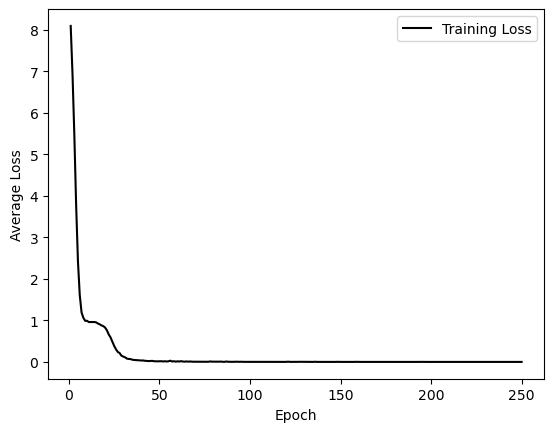

In [10]:
# Plotting,
epochs = np.arange(start=1, stop=len(train_losses)+1, step=1)
plt.plot(epochs, train_losses, color="black", label="Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.legend()
plt.show()

### 5. Model Predictions

We write a function for model inference,

In [11]:
def predict(model, dataloader, device="cpu"):
    """This function perform model inference."""

    model.eval() # <-- Switching to evaluation mode.
    X_input = []
    y_preds = []
    y_truth = []

    with torch.no_grad():
        for (X, y) in dataloader:

            # Switching devices,
            X = X.to(device).float()
            y = y.to(device).float()

            # Forward pass,
            y_pred = model(X)

            # Tracking,
            y_preds.append(y_pred.cpu())
            y_truth.append(y.cpu())
            X_input.append(X.cpu())

    # Converting into Numpy arrays,
    y_preds = np.squeeze(torch.cat(y_preds, dim=0).numpy())
    y_truth = np.squeeze(torch.cat(y_truth, dim=0).numpy())
    X_input = np.squeeze(torch.cat(X_input, dim=0).numpy())

    return X_input, y_preds, y_truth

Visualising the model predictions,


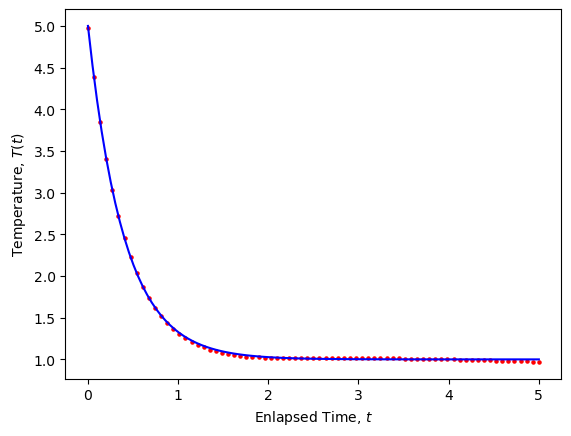

In [12]:
def solution(t, alpha, T_0, T_s):
    return T_s + (T_0 - T_s)*np.exp(-alpha*t)

# Parameters
alpha = 2.5
T_0 = 5
T_s = 1

# Computing analytical solution,
t = np.linspace(start=0, stop=5, num=100)
sol = solution(t, alpha, T_0, T_s)

# Computing model predictions,
X_test, y_preds, y_truth = predict(model, dataloader=test_loader, device=device)

# Plotting,
plt.plot(t, sol, color="blue")
plt.xlabel("Enlapsed Time, $t$")
plt.ylabel("Temperature, $T(t)$")
plt.scatter(X_test, y_preds, s=5, color="red")
plt.show()